In [135]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from cuda_cqed.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

# Hamiltonian


$$
H = \sigma_z \chi a^{\dagger} a + 6 g_3 \lambda_{ab} (\eta_1 a^{\dagger} b  + \eta_1^* a b^{\dagger}) + 2 |\eta_1|^2 b^{\dagger} b K_4
$$

# Heisenberg EoM calcs

In [434]:
from openfermion.ops import BosonOperator
from openfermion.transforms import normal_ordered
from openfermion.utils import commutator

from sympy import symbols
import numpy as np
K4, g3, eta_1, conj_eta_1 = symbols('K4, g_3, eta_1, conj_eta_1', real=True)
chi, lambda_ab = symbols('chi, lambda_ab', real=True)

H_lin = BosonOperator('0^ 0', chi)
H_kerr = BosonOperator('1^ 1^ 1 1', K4)
H_stark = BosonOperator('1^ 1', 2*K4*conj_eta_1*eta_1)
H_parametric = 6*g3*lambda_ab*(conj_eta_1*BosonOperator('0^ 1')+eta_1*BosonOperator('0 1^'))

H = H_lin + H_parametric + H_stark
H

6.0*eta_1*g_3*lambda_ab [0 1^] +
chi [0^ 0] +
6.0*conj_eta_1*g_3*lambda_ab [0^ 1] +
2*K4*conj_eta_1*eta_1 [1^ 1]

In [435]:
def openfermion2numpy(OF_exp):

    exp_string_full = str(OF_exp) + ' '
    exp_string_arr = exp_string_full.split('\n')
    
    eom_string = ''

    for exp_string in exp_string_arr:
        
        eom_term_string = exp_string
        
        prefactor_str = exp_string.split('[')[0]
#         op_strs = exp_string.split('[')[1]
#         op_strs = op_strs.replace(']', '')
#         op_strs = op_strs.replace('+', '').split(' ')

        eom_term_string = eom_term_string.replace(' [0]', ')*a')
        eom_term_string = eom_term_string.replace(' [0^]', ')*conjugate(a)')
        eom_term_string = eom_term_string.replace(' [0^ 0]', ')*adaga')
        eom_term_string = eom_term_string.replace(' [0 0]', ')*aa')
        eom_term_string = eom_term_string.replace(' [0^ 0^]', ')*conjugate(aa)')
        eom_term_string = eom_term_string.replace(' [0^ 1]', ')*adagb')
        eom_term_string = eom_term_string.replace(' [0 1]', ')*ab')
        eom_term_string = eom_term_string.replace(' [0 1^]', ')*conjugate(adagb)')
        eom_term_string = eom_term_string.replace(' [0^ 1^]', ')*conjugate(ab)')
        eom_term_string = eom_term_string.replace(' [1]', ')*b')
        eom_term_string = eom_term_string.replace(' [1^]', ')*conjugate(b)')
        eom_term_string = eom_term_string.replace(' [1^ 1]', ')*bdagb')
        eom_term_string = eom_term_string.replace(' [1 1]', ')*bb')
        eom_term_string = eom_term_string.replace(' [1^ 1^]', ')*conjugate(bb)')
        eom_term_string = eom_term_string.replace('[1^ 1 1]', ')*bdagb*b')
        eom_term_string = eom_term_string.replace('[1^ 1 1 1]', ')*bdagb*bb')
        eom_term_string = eom_term_string.replace('[0 1^ 1 1]', ')*conjugate(adagb)*bb')
        eom_term_string = eom_term_string.replace('[0^ 1^ 1 1]', ')*conjugate(ab)*bb')
        eom_term_string = eom_term_string.replace('[1^ 1 1 2]', ')*conjugate(bdagb)*bc')
        eom_term_string = eom_term_string.replace('[1^ 1^ 1 2]', ')*conjugate(bb)*bc')

        eom_string += '(' + eom_term_string

    eom_string = eom_string.replace('*I', '*1j')
    eom_string = eom_string.replace(' [] ', '')
    
    eom_string = eom_string.replace('conj_eta_1', 'conjugate(eta_1)')
    eom_string = eom_string.replace('conj_eta_2', 'conjugate(eta_2)')
    eom_string = eom_string.replace('conj_eta_3', 'conjugate(eta_3)')
    eom_string = eom_string.replace('eta_sum', '(abs(eta_1)**2+abs(eta_2)**2+abs(eta_3)**2)')
    
#     eom_string = eom_string.replace('[0^ 2^]', '(abs(eta_1)**2+abs(eta_2)**2+abs(eta_3)**2)')
    
    return eom_string
                
OF_string = normal_ordered(1j*commutator(H, BosonOperator('0 1')))
print(H)
print(OF_string)
eom_string = openfermion2numpy(OF_string)
print('Eom str: ' + eom_string)


6.0*eta_1*g_3*lambda_ab [0 1^] +
chi [0^ 0] +
6.0*conj_eta_1*g_3*lambda_ab [0^ 1] +
2*K4*conj_eta_1*eta_1 [1^ 1]
-6.0*I*eta_1*g_3*lambda_ab [0 0] +
-2.0*I*K4*conj_eta_1*eta_1 - 1.0*I*chi [0 1] +
-6.0*I*conj_eta_1*g_3*lambda_ab [1 1]
Eom str: (-6.0*1j*eta_1*g_3*lambda_ab)*aa +(-2.0*1j*K4*conjugate(eta_1)*eta_1 - 1.0*1j*chi)*ab +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*bb 


In [436]:
normal_ordered(commutator(BosonOperator('0^ 0', chi)+BosonOperator('1^ 1', K4), BosonOperator('0 1')))

-1.0*K4 - 1.0*chi [0 1]

In [437]:
print("sim.add_EOM('a', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('0')))), "', IC_str='init_a')")
print("sim.add_EOM('aa', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('0 0')))), "', IC_str='init_a**2')")
print("sim.add_EOM('adaga', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('0^ 0')))), "', IC_str='init_a**2')")
print("sim.add_EOM('b', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('1')))), "')")
print("sim.add_EOM('bb', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('1 1')))), "')")
print("sim.add_EOM('bdagb', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('1^ 1')))), "')")
print("sim.add_EOM('ab', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('0 1')))), "')")
print("sim.add_EOM('adagb', '", openfermion2numpy(normal_ordered(1j*commutator(H, BosonOperator('0^ 1')))), "')")

sim.add_EOM('a', ' (-1.0*1j*chi)*a +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*b  ', IC_str='init_a')
sim.add_EOM('aa', ' (-2.0*1j*chi)*aa +(-12.0*1j*conjugate(eta_1)*g_3*lambda_ab)*ab  ', IC_str='init_a**2')
sim.add_EOM('adaga', ' (6.0*1j*eta_1*g_3*lambda_ab)*conjugate(adagb) +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*adagb  ', IC_str='init_a**2')
sim.add_EOM('b', ' (-6.0*1j*eta_1*g_3*lambda_ab)*a +(-2.0*1j*K4*conjugate(eta_1)*eta_1)*b  ')
sim.add_EOM('bb', ' (-12.0*1j*eta_1*g_3*lambda_ab)*ab +(-4.0*1j*K4*conjugate(eta_1)*eta_1)*bb  ')
sim.add_EOM('bdagb', ' (-6.0*1j*eta_1*g_3*lambda_ab)*conjugate(adagb) +(6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*adagb  ')
sim.add_EOM('ab', ' (-6.0*1j*eta_1*g_3*lambda_ab)*aa +(-2.0*1j*K4*conjugate(eta_1)*eta_1 - 1.0*1j*chi)*ab +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*bb  ')
sim.add_EOM('adagb', ' (-6.0*1j*eta_1*g_3*lambda_ab)*adaga +(-2.0*1j*K4*conjugate(eta_1)*eta_1 + 1.0*1j*chi)*adagb +(6.0*1j*eta_1*g_3*lambda_ab)*bdagb  ')


# Cumulant equations


<!-- the Heisenberg EoMs are
$$
\dot{ <b> } = - i \omega_b <b> - 6 i \eta g_3 \lambda <c> - 2i K_4 <b^{\dagger} b > <b>
$$
$$
\dot{<b^{\dagger} b>} = +6 i \eta^* g_3 \lambda <b^{\dagger}c>^* - 6 i \eta g_3 \lambda <b^{\dagger}c>
$$

$$
\dot{ <c> } = - i \omega_c <c> - 6 i \eta^* g_3 \lambda <b>
$$
$$
\dot{<c^{\dagger} c>} = -6 i \eta^* g_3 \lambda <b^{\dagger}c>^* + 6 i \eta g_3 \lambda <b^{\dagger}c>
$$

$$
\dot{ <b^{\dagger} c> } = - 6i \eta^* g_3 \lambda <b^{\dagger} b> + i (\omega_b - \omega_c) <b^{\dagger}c> + 6 \eta^* g_3 \lambda <c^{\dagger} c> + 2i K_4 <b^{\dagger} c> <b^{\dagger} b>
$$


Adding the static loss terms
$$
\dot{ <b> } = - i \omega_b <b> - 6 i \eta g_3 \lambda <c> - 2i K_4 <b^{\dagger} b > <b> - \kappa_b/2 <b>
$$
$$
\dot{<b^{\dagger} b>} = +6 i \eta^* g_3 \lambda <b^{\dagger}c>^* - 6 i \eta g_3 \lambda <b^{\dagger}c>  - \kappa_b <b^{\dagger} b>
$$

$$
\dot{ <c> } = - i \omega_c <c> - 6 i \eta^* g_3 \lambda <b> - \kappa_c/2 <c>
$$
$$
\dot{<c^{\dagger} c>} = -6 i \eta^* g_3 \lambda <b^{\dagger}c>^* + 6 i \eta g_3 \lambda <b^{\dagger}c> - \kappa_c <c^{\dagger} c>
$$

$$
\dot{ <b^{\dagger} c> } = - 6i \eta^* g_3 \lambda <b^{\dagger} b> + i (\omega_b - \omega_c) <b^{\dagger}c> + 6 i \eta^* g_3 \lambda <c^{\dagger} c> + 2i K_4 <b^{\dagger} c> <b^{\dagger} b> - \frac{\kappa_b + \kappa_c}{2} <b^{\dagger} c>
$$
 -->

In [438]:
pi = np.pi

sim = Sim(use_complex=True)

chi = 0e6*2*pi
eta = 1
g3 = 10e6*2*np.pi
IC = 1
K = 1e6 * 2 * np.pi

lambda_ab = 0.1
sim.add_param('chi', chi, is_excitation=True)
sim.add_param('g_3', g3)
sim.add_param('K4', K)
sim.add_param('lambda_ab', lambda_ab)
sim.add_param('ka', 0.5e6*2*np.pi)
sim.add_param('kb', 0.5e6*2*np.pi)

# sim.add_paramsweep('wCONV1', -1e6 * 2 * np.pi,  1e6 * 2 * np.pi, 51)
# sim.add_paramsweep('amplCONV1', 0, 12, 101)
sim.add_param('wCONV1', 0)
sim.add_param('amplCONV1', eta)
sim.add_param('phaseCONV1', 0)
sim.add_param('startCONV1', 30e-9)
sim.add_param('stopCONV1', 120e-9)
sim.add_param('rampCONV1', 5e-9)

sim.add_param('init_a', IC)
sim.add_param('init_b', 0)
sim.add_param('init_c', 0)

CONV1 = sim.make_pulse('wCONV1', 'amplCONV1', 'phaseCONV1', 'startCONV1', 'stopCONV1', 'rampCONV1')

sim.add_EOM('eta_1', '0', IC_str='amplCONV1')

sim.add_EOM('a', ' (-1.0*1j*chi)*a +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*b  ', IC_str='init_a')
sim.add_EOM('aa', ' (-2.0*1j*chi)*aa +(-12.0*1j*conjugate(eta_1)*g_3*lambda_ab)*ab  ', IC_str='init_a**2')
sim.add_EOM('adaga', ' (6.0*1j*eta_1*g_3*lambda_ab)*conjugate(adagb) +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*adagb  ', IC_str='init_a**2')
sim.add_EOM('b', ' (-6.0*1j*eta_1*g_3*lambda_ab)*a +(-2.0*1j*K4*conjugate(eta_1)*eta_1)*b  ')
sim.add_EOM('bb', ' (-12.0*1j*eta_1*g_3*lambda_ab)*ab +(-4.0*1j*K4*conjugate(eta_1)*eta_1)*bb  ')
sim.add_EOM('bdagb', ' (-6.0*1j*eta_1*g_3*lambda_ab)*conjugate(adagb) +(6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*adagb  ')
sim.add_EOM('ab', ' (-6.0*1j*eta_1*g_3*lambda_ab)*aa +(-2.0*1j*K4*conjugate(eta_1)*eta_1 - 1.0*1j*chi)*ab +(-6.0*1j*conjugate(eta_1)*g_3*lambda_ab)*bb  ')
sim.add_EOM('adagb', ' (-6.0*1j*eta_1*g_3*lambda_ab)*adaga +(-2.0*1j*K4*conjugate(eta_1)*eta_1 + 1.0*1j*chi)*adagb +(6.0*1j*eta_1*g_3*lambda_ab)*bdagb  ')


sim.set_solve_type('all')

sim.specify_time(t_f=0.15e-6, pts=1001)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


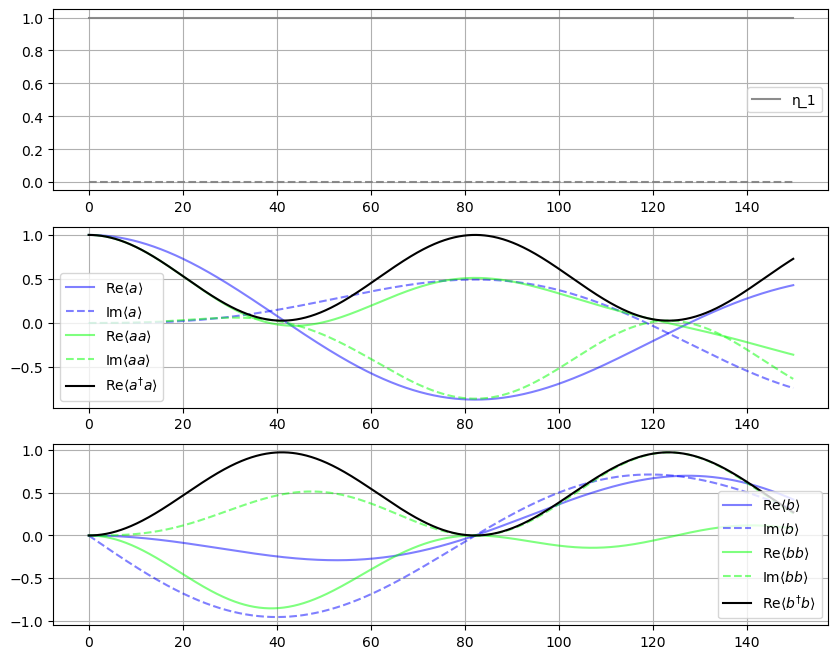

In [439]:
x, tlist = sim.quick_trace()

eta_scale = 1

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,8))


axs[0].plot(tlist*1e9, x[0,:]/eta_scale,color=(0.5,0.5,0.5,0.9),label='η_1')
axs[0].plot(tlist*1e9, x[1,:]/eta_scale,'--',color=(0.5,0.5,0.5,0.9))

axs[0].grid()
axs[0].legend()

axs[1].plot(tlist*1e9, x[2,:],color=(0,0,1,0.5),label=r'Re$\langle a \rangle $')
axs[1].plot(tlist*1e9, x[3,:],'--',color=(0,0,1,0.5),label=r'Im$\langle a \rangle $')

axs[1].plot(tlist*1e9, x[4,:],color=(0,1,0,0.5),label=r'Re$\langle aa \rangle $')
axs[1].plot(tlist*1e9, x[5,:],'--',color=(0,1,0,0.5),label=r'Im$\langle aa \rangle $')

axs[1].plot(tlist*1e9, x[6,:],color='k',label=r'Re$\langle a^{\dagger}a \rangle $')
axs[1].grid()
axs[1].legend()

axs[2].plot(tlist*1e9, x[8,:],color=(0,0,1,0.5),label=r'Re$\langle b \rangle $')
axs[2].plot(tlist*1e9, x[9,:],'--',color=(0,0,1,0.5),label=r'Im$\langle b \rangle $')

axs[2].plot(tlist*1e9, x[10,:],color=(0,1,0,0.5),label=r'Re$\langle bb \rangle $')
axs[2].plot(tlist*1e9, x[11,:],'--',color=(0,1,0,0.5),label=r'Im$\langle bb \rangle $')

axs[2].plot(tlist*1e9, x[12,:],color='k',label=r'Re$\langle b^{\dagger}b \rangle $')
axs[2].grid()
axs[2].legend()

plt.show()

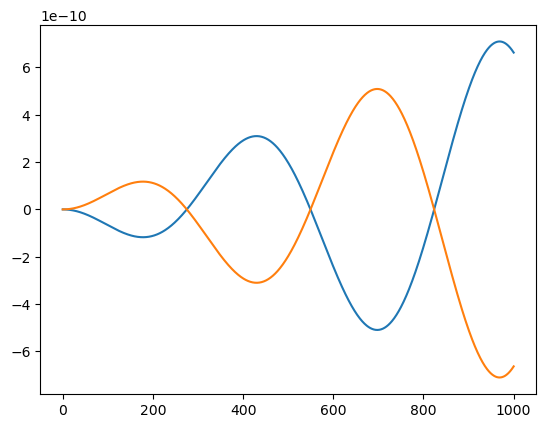

In [440]:
plt.plot(np.abs(x[2,:]+1j*x[3,:])**2-x[6,:])
plt.plot(np.abs(x[8,:]+1j*x[9,:])**2-x[12,:])
plt.show()

In [441]:
a_c = x[2,:]+1j*x[3,:]
aa_c = x[4,:]+1j*x[5,:]
adaga_c = x[6,:]+1j*x[7,:]
b_c = x[8,:]+1j*x[9,:]
bb_c = x[10,:]+1j*x[11,:]
bdagb_c = x[12,:]+1j*x[13,:]


# QuTiP

In [442]:
from base64 import b64encode

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from qutip import (about, basis, coherent, destroy, tensor, qeye, displace, expect, mesolve,
                   num, plot_fock_distribution, plot_wigner, squeeze, variance, Options)

%matplotlib inline

In [447]:
N = 20

# operators
a = tensor(destroy(N), qeye(N))
na = a.dag()*a
xa = (a + a.dag()) / np.sqrt(2)
pa = -1j * (a - a.dag()) / np.sqrt(2)

b = tensor(qeye(N), destroy(N))
nb = b.dag()*b
xb = (b + b.dag()) / np.sqrt(2)
pb = -1j * (b - b.dag()) / np.sqrt(2)

H0 = chi*a.dag()*a + 2*K*np.abs(eta)**2*b.dag()*b
# H0 = chi*a.dag()*a + K*b.dag()*b.dag()*b*b

H1 = 6*g3*lambda_ab*a.dag()*b
H2 = 6*g3*lambda_ab*a*b.dag()

H = [H0, [H1, eta], [H2, np.conjugate(eta)]]

c_ops = [0.0*a]



In [448]:
def plot_expect_with_variance(N, op_list, op_title, states):
    """
    Plot the expectation value of an operator (list of operators)
    with an envelope that describes the operators variance.
    """

    fig, axes = plt.subplots(1, len(op_list), figsize=(14, 3))

    for idx, op in enumerate(op_list):

        e_op = expect(op, states)
        v_op = variance(op, states)

        axes[idx].fill_between(
            tlist, e_op - np.sqrt(v_op), e_op + np.sqrt(v_op), color="green",
            alpha=0.5)
        axes[idx].plot(tlist, e_op, label="expectation")
        axes[idx].set_xlabel("Time")
        axes[idx].set_title(op_title[idx])

    return fig, axes

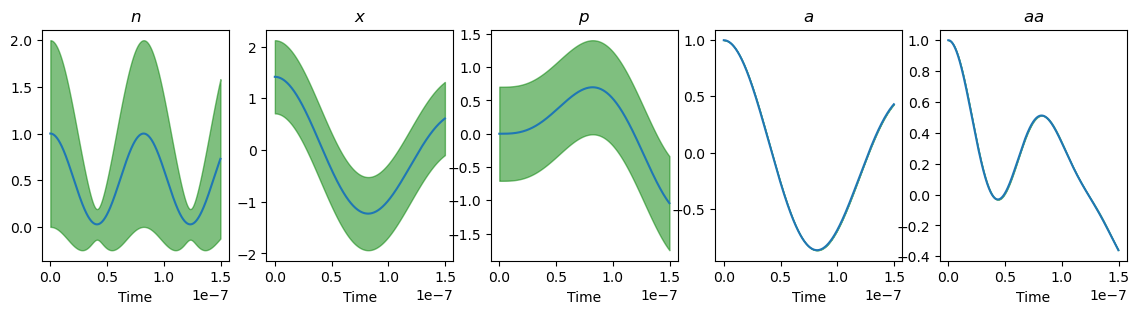

In [449]:
psi0 = tensor(coherent(N, IC), coherent(N,0))

result = mesolve(H, psi0, t, c_ops, [])

plot_expect_with_variance(N, [na, xa, pa, a, a*a], [r"$n$", r"$x$", r"$p$",  r"$a$",  r"$aa$"],
                          result.states);
plt.show()

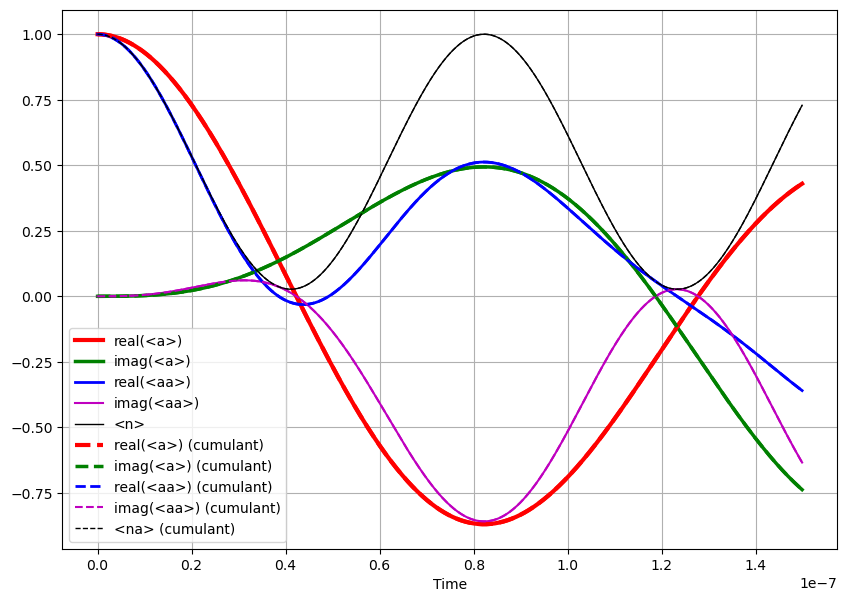

In [450]:
plt.figure(figsize=(10,7))
plt.plot(tlist,np.real(expect(a, result.states)),'r-',label='real(<a>)',linewidth=3)
plt.plot(tlist,np.imag(expect(a, result.states)),'g-',label='imag(<a>)',linewidth=2.5)
plt.plot(tlist,np.real(expect(a*a, result.states)),'b-',label='real(<aa>)',linewidth=2)
plt.plot(tlist,np.imag(expect(a*a, result.states)),'m-',label='imag(<aa>)',linewidth=1.5)
plt.plot(tlist,expect(a.dag()*a, result.states),'k-',label='<n>',linewidth=1)

plt.plot(tlist,np.real(a_c),'r--',label='real(<a>) (cumulant)',linewidth=3)
plt.plot(tlist,np.imag(a_c),'g--',label='imag(<a>) (cumulant)',linewidth=2.5)
plt.plot(tlist,np.real(aa_c),'b--',label='real(<aa>) (cumulant)',linewidth=2)
plt.plot(tlist,np.imag(aa_c),'m--',label='imag(<aa>) (cumulant)',linewidth=1.5)
plt.plot(tlist,np.real(adaga_c),'k--',label='<na> (cumulant)',linewidth=1)
# plt.xlim([0,30])
# plt.ylim([-0.1,0.1])
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.show()